$$
X^\top X \, \theta = X^\top y
$$ \\
$$
\hat{\theta} = (X^\top X)^{-1} X^\top y
$$

​

In [ ]:
import numpy as np
X = np.array([[1,2],[3,4],[5,6]],dtype=float)
y = np.array([2,4,5],dtype=float)
theta = np.linalg.inv(X.T @ X) @ X.T @ y
print(f'θ₀ = {theta[0]:.4f}')
print(f'θ₁ = {theta[1]:.4f}')

θ₀ = -0.6667
θ₁ = 1.4167


模型                        MAE     RMSE       R²
--------------------------------------------------
Linear Regression      0.5332   0.7456   0.5758
SGD Regressor          0.5334   0.7452   0.5763


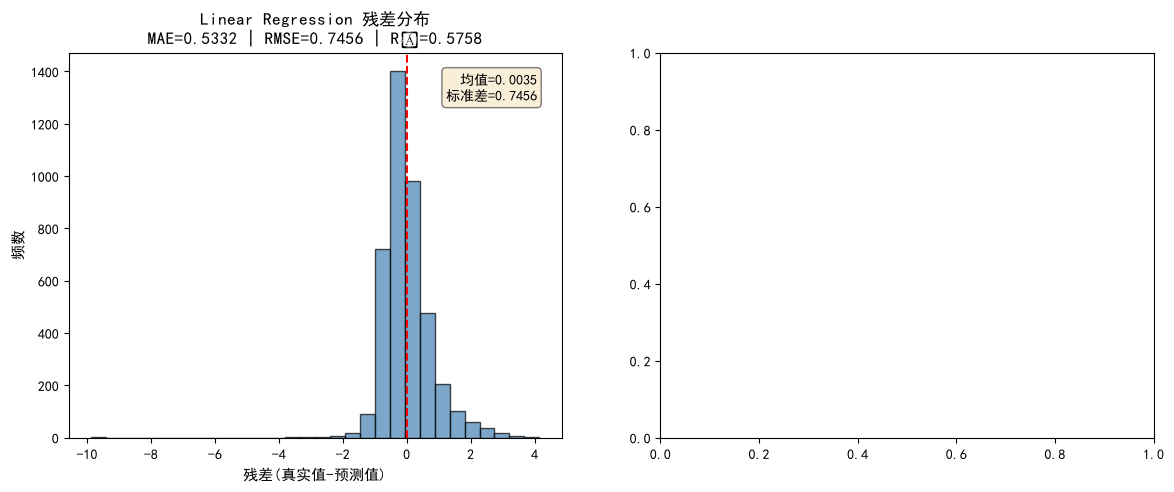

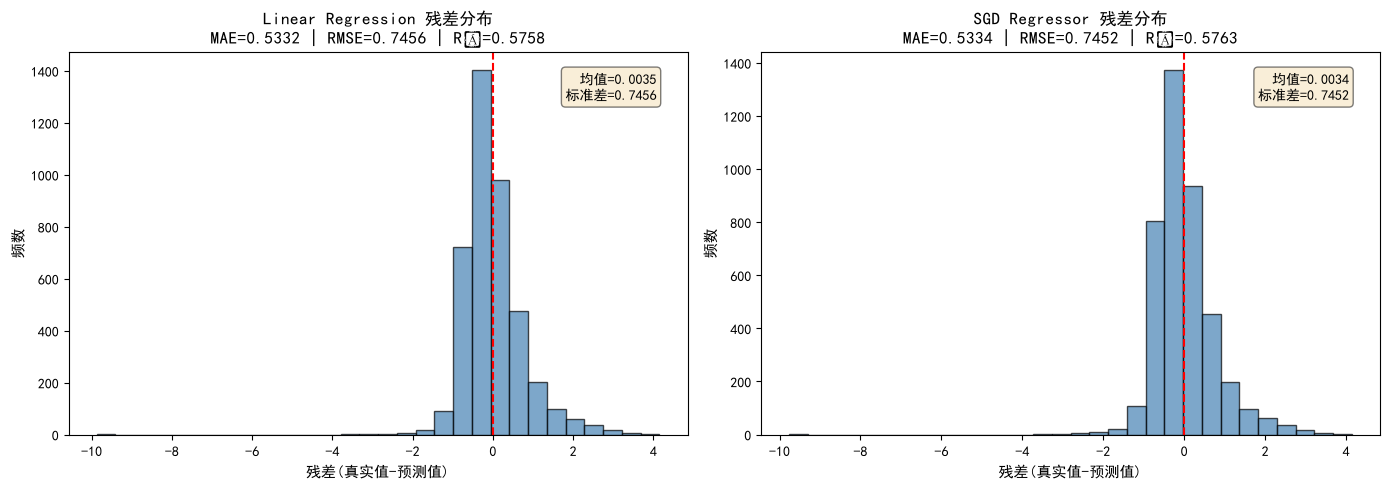

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei','Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
data = fetch_california_housing()
X,y = data.data,data.target
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
models = {
    'Linear Regression':LinearRegression(),
    'SGD Regressor':SGDRegressor(
        loss='squared_error',#普通最小二乘法
        learning_rate='adaptive',#自适应学习率
        eta0=0.01,#初始学习率
        max_iter=1000,#最大迭代次数
        tol=1e-4,#停止准则
        random_state=42#随机种子，确保实验可重复
    )
}
results = {}
predictions = {}
print(f"{'模型':<20} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("-" * 50)
for name,model in models.items():
    if name == 'SGD Regressor':
        model.fit(X_train_scaled,y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train,y_train)
        y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test,y_pred)
    rmse = np.sqrt(mean_squared_error(y_test,y_pred))
    r2 = r2_score(y_test,y_pred)
    results[name] = {'MAE':mae,'RMSE':rmse,'R²':r2}
    predictions[name] = y_pred
    print(f'{name:<20} {mae:>8.4f} {rmse:>8.4f} {r2:>8.4f}')
    fig,axes = plt.subplots(1,2,figsize=(14,5))
    for ax,(name,y_pred) in zip(axes,predictions.items()):
        residuals = y_test - y_pred
        ax.hist(residuals,bins=30,edgecolor='black',alpha=0.7,color='steelblue')
        ax.axvline(x=0,color='red',linestyle='--',linewidth=1.5)
        ax.set_title(f'{name} 残差分布\n'
                     f'MAE={results[name]["MAE"]:.4f} | '
                     f'RMSE={results[name]["RMSE"]:.4f} | '
                     f'R²={results[name]["R²"]:.4f}', fontsize=12)
        ax.set_xlabel('残差(真实值-预测值)',fontsize=11)
        ax.set_ylabel('频数',fontsize=11)
        mean_res = np.mean(residuals)
        std_res = np.std(residuals)
        ax.text(0.95, 0.95, f'均值={mean_res:.4f}\n标准差={std_res:.4f}',
            transform=ax.transAxes, ha='right', va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()




### 线性回归预测公式

$$\hat{y} = \mathbf{w}^\top \mathbf{x} + b = \sum_{i=1}^{n} w_i x_i + b$$

其中：
- $\hat{y}$：预测值
- $\mathbf{w} \in \mathbb{R}^n$：权重向量
- $\mathbf{x} \in \mathbb{R}^n$：特征向量
- $b \in \mathbb{R}$：偏置项

$$J(\mathbf{w}, b) = \frac{1}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i)^2 = \frac{1}{N} \| \mathbf{X}\mathbf{w} + b \cdot \mathbf{1} - \mathbf{y} \|^2$$

$$\mathbf{w}^{(t+1)} \leftarrow \mathbf{w}^{(t)} - \eta \nabla_{\mathbf{w}} J = \mathbf{w}^{(t)} - \eta \cdot \frac{2}{N} \mathbf{X}^\top (\mathbf{X}\mathbf{w}^{(t)} - \mathbf{y})$$

$$
\begin{aligned}
\text{MAE} &= \frac{1}{N} \sum_{i=1}^{N} |y_i - \hat{y}_i| \\[8pt]
\text{RMSE} &= \sqrt{\text{MSE}} = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2} \\[8pt]
R^2 &= 1 - \frac{\sum_{i=1}^{N} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{N} (y_i - \bar{y})^2}
\end{aligned}
$$